[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/05_mechanistic_decomposition.ipynb)

In [1]:
from pathlib import Path
import os, sys, subprocess


def _running_in_colab() -> bool:
    return "COLAB_RELEASE_TAG" in os.environ or "google.colab" in sys.modules


if _running_in_colab():
    repo_url = os.environ.get("ASTROMODEL_REPO_URL", "https://github.com/doxav/astromodel_proving.git")
    repo_branch = os.environ.get("ASTROMODEL_REPO_BRANCH", "main")
    project_root = Path("/content") / "astromodel_proving"
    if not project_root.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--branch", repo_branch, repo_url, str(project_root)], check=True)
    os.chdir(project_root)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    project_root = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
    os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /workspace/astromodel_proving


# Step 05 — Mechanistic decomposition of accepted cell ensembles

This notebook validates the Step 05 reviewer-response pipeline. It loads accepted Step 04 cell-level ensembles, simulates hidden outputs with the canonical local astrocyte model, decomposes accepted fits into Kir/gap/leak mechanism summaries, clusters in effective/mechanism space, and records conservative claim scope.

The implementation reuses the local model and ATF conventions developed from `analysis/astro_atf_analysis_improved_sectioned.ipynb`. Step 05 can identify candidate mechanism regimes or compensation manifolds, but predictive and perturbation support remains pending until Step 06.

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

from src.step05_mechanistic_decomposition import Step05Config, run_step05_mechanistic_decomposition

config = Step05Config(
    max_candidates=4,
    time_points=120,
    bootstrap_iterations=8,
    random_seed=13,
    min_candidates_for_multicluster=6,
    min_cells_for_multicluster=3,
    min_cells_per_cluster=2,
    proxy_failure_downgrade_fraction=0.5,
    write_outputs=True,
)
result = run_step05_mechanistic_decomposition(project_root, config)
out_dir = project_root / "outputs" / "mechanisms"
print(json.dumps(result["analysis_summary"], indent=2))


{
  "step_name": "Step 05 \u2014 Mechanistic decomposition of accepted cell ensembles",
  "input_source": "outputs/cell_fits/accepted_cell_ensembles.csv",
  "config": {
    "max_candidates": 4,
    "time_points": 120,
    "t_final_ms": 50000.0,
    "n_clusters": 3,
    "bootstrap_iterations": 8,
    "random_seed": 13,
    "max_representatives": 3,
    "interpolation_points": 5,
    "small_stratum_min_cells": 3,
    "min_candidates_for_multicluster": 6,
    "min_cells_for_multicluster": 3,
    "min_cells_per_cluster": 2,
    "proxy_failure_downgrade_fraction": 0.5,
    "write_outputs": true
  },
  "n_input_candidates": 4,
  "n_candidate_sweep_rows": 24,
  "n_successful_sweep_simulations": 24,
  "n_mechanism_clusters": 1,
  "n_independent_cells": 2,
  "cluster_evidence_status": "insufficient_evidence",
  "cluster_evidence_reason": "needs >= 6 candidates and >= 3 independent cells; observed 4 candidates and 2 cells",
  "headline_claim_scope": "insufficient_evidence_for_candidate_mechanism

## 1. Accepted ensemble inventory

In [3]:
clusters = result["mechanism_clusters"]
flux = result["accepted_fit_mechanisms"]
inventory = clusters.groupby(["region", "condition"], as_index=False).agg(
    n_cells=("file_id", "nunique"),
    n_candidates=("candidate_id", "nunique"),
    n_clusters=("mechanism_cluster", "nunique"),
)
inventory

,region,condition,n_cells,n_candidates,n_clusters
0,DH,CONTROL,1,3,1
1,DH,MFA,1,1,1


## 2. Candidate-sweep flux decomposition table

In [4]:
flux_cols = [
    "file_id", "region", "condition", "candidate_id", "sweep", "current_na", "simulation_status",
    "I_Kir_integral", "I_kgap_integral", "I_leak_integral", "gap_to_kir_integral_ratio",
    "gap_fraction", "kir_fraction", "leak_fraction", "K_o_peak", "K_o_recovery_error", "proxy_validity_class",
]
flux[flux_cols].head(12)

,file_id,region,condition,candidate_id,sweep,current_na,simulation_status,I_Kir_integral,I_kgap_integral,I_leak_integral,gap_to_kir_integral_ratio,gap_fraction,kir_fraction,leak_fraction,K_o_peak,K_o_recovery_error,proxy_validity_class
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,1,50,ok,6623.715986,6627.338832,3.635322,1.000547,0.500000,0.499726,0.000274,5.165366,0.008856,failed
1,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,2,75,ok,9082.821289,9086.331585,3.530811,1.000386,0.499999,0.499806,0.000194,5.536322,0.008856,failed
2,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,3,100,ok,11966.453507,11969.831831,3.408237,1.000282,0.499999,0.499858,0.000142,5.968027,0.008856,failed
3,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,4,125,ok,15832.437526,15835.638715,3.243889,1.000202,0.499999,0.499898,0.000102,6.546368,0.008856,failed
4,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,5,150,ok,17613.352664,17616.472110,3.168175,1.000177,0.499999,0.499911,0.000090,6.813934,0.008856,failed
5,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,6,175,ok,18798.610342,18801.675324,3.117784,1.000163,0.499999,0.499918,0.000083,6.992690,0.008856,failed
6,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,1,50,ok,6301.691440,6305.200670,3.534110,1.000557,0.499999,0.499721,0.000280,5.225579,0.008983,failed
7,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,2,75,ok,8616.741179,8620.095037,3.393549,1.000389,0.499999,0.499804,0.000197,5.623407,0.008983,failed
8,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,3,100,ok,11316.326910,11319.499187,3.229614,1.000280,0.499999,0.499859,0.000143,6.089442,0.008983,failed
9,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,4,125,ok,14911.383860,14914.313392,3.011278,1.000196,0.499999,0.499900,0.000101,6.718315,0.008983,failed


## 2b. Protocol and K bath audit

Step 05 must not collapse the six current protocol into repeated 100 nA bath-drive simulations. The model already knows the historical current-specific bath values; Step 05 only applies explicit per-sweep/per-current/affine/gain overrides when they are present.


In [5]:
protocol_cols = [
    "candidate_id",
    "current_na",
    "sweep",
    "K_bath_middle_used",
    "K_bath_override_mode",
    "stim_window_start_s",
    "stim_window_end_s",
    "K_o_peak",
    "K_o_recovery_error",
]
protocol_audit = flux[protocol_cols].sort_values(["candidate_id", "current_na"])
protocol_summary = flux.groupby("candidate_id", as_index=False).agg(
    n_currents=("current_na", "nunique"),
    n_unique_kbath=("K_bath_middle_used", "nunique"),
    min_kbath=("K_bath_middle_used", "min"),
    max_kbath=("K_bath_middle_used", "max"),
    override_modes=("K_bath_override_mode", lambda s: ";".join(sorted(set(map(str, s))))),
)
protocol_summary


,candidate_id,n_currents,n_unique_kbath,min_kbath,max_kbath,override_modes
0,1_DH_1__cand_01__base,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
1,1_DH_1__cand_02__low_gap,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
2,1_DH_1__cand_03__high_gap,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain
3,DH_1_MFA__cand_01__base,6,6,6.4,10.5,historical_current_kbath_scaled_by_gain


## 3. Mechanism-space clustering

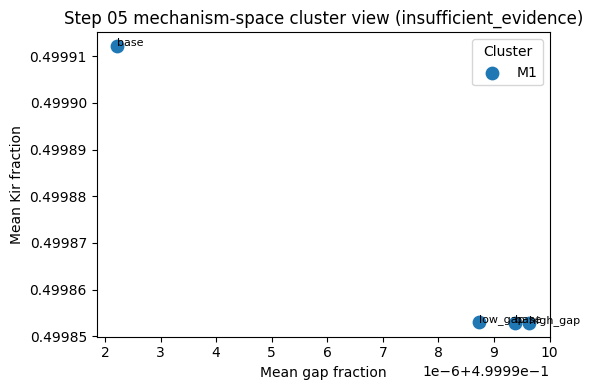

In [6]:
cluster_evidence = clusters[[
    "file_id", "candidate_id", "mechanism_cluster", "cluster_evidence_status",
    "cluster_evidence_reason", "cluster_claim_scope", "proxy_validity_status",
]].drop_duplicates()
cluster_evidence

fig, ax = plt.subplots(figsize=(6, 4))
for label, sub in clusters.groupby("mechanism_cluster"):
    ax.scatter(sub["gap_fraction_mean"], sub["kir_fraction_mean"], s=80, label=label)
for _, row in clusters.iterrows():
    ax.annotate(str(row["candidate_id"]).split("__")[-1], (row["gap_fraction_mean"], row["kir_fraction_mean"]), fontsize=8)
ax.set_xlabel("Mean gap fraction")
ax.set_ylabel("Mean Kir fraction")
evidence_status = str(clusters["cluster_evidence_status"].iloc[0]) if "cluster_evidence_status" in clusters else "unknown"
ax.set_title(f"Step 05 mechanism-space cluster view ({evidence_status})")
ax.legend(title="Cluster")
fig.tight_layout()
plt.show()


## 4. Flux decomposition for representative candidates

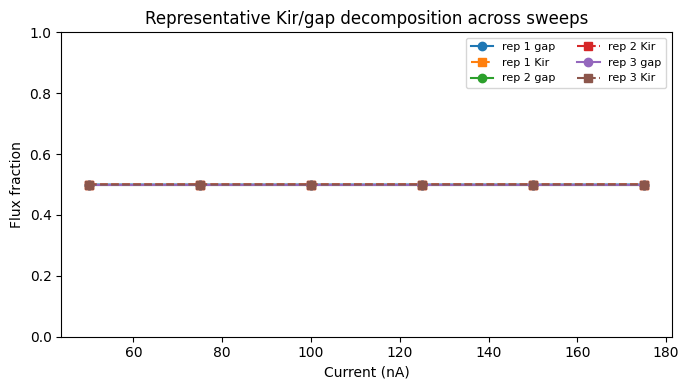

,representative_rank,file_id,condition,mechanism_cluster,dominant_mechanism,claim_scope
0,1,DH_1_MFA,MFA,M1,Mixed,insufficient_evidence_for_candidate_mechanism_...
1,2,1_DH_1,CONTROL,M1,Mixed,insufficient_evidence_for_candidate_mechanism_...
2,3,1_DH_1,CONTROL,M1,Mixed,insufficient_evidence_for_candidate_mechanism_...


In [7]:
reps = result["representatives"]
rep_flux = flux.merge(reps[["file_id", "candidate_id", "representative_rank"]], on=["file_id", "candidate_id"], how="inner")
fig, ax = plt.subplots(figsize=(7, 4))
for (rank, candidate_id), sub in rep_flux.groupby(["representative_rank", "candidate_id"]):
    sub = sub.sort_values("current_na")
    ax.plot(sub["current_na"], sub["gap_fraction"], marker="o", label=f"rep {rank} gap")
    ax.plot(sub["current_na"], sub["kir_fraction"], marker="s", linestyle="--", label=f"rep {rank} Kir")
ax.set_xlabel("Current (nA)")
ax.set_ylabel("Flux fraction")
ax.set_ylim(0, 1)
ax.set_title("Representative Kir/gap decomposition across sweeps")
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
plt.show()
reps[["representative_rank", "file_id", "condition", "mechanism_cluster", "dominant_mechanism", "claim_scope"]]

## 5. Compensation-vs-separated-mode interpolation diagnostics

In [8]:
geometry = result["geometry_classification"]
geometry[["cluster_a", "cluster_b", "geometry_screen_type", "interpolation_status", "geometry_classification", "validation_status"]]


,cluster_a,cluster_b,geometry_screen_type,interpolation_status,geometry_classification,validation_status
0,M1,none,not_run_insufficient_cluster_evidence,not_run,insufficient_evidence,pending_step06


## 6. Bootstrap stability table

In [9]:
stability = result["bootstrap_cluster_stability"]
stability


,bootstrap_iteration,n_cells,n_candidates,coassignment_stability,stability_status,stability_reason
0,0,2,4,NaN,insufficient_evidence,needs >= 6 candidates and >= 3 independent cel...


## 7. DH/VH and condition occupancy table

In [10]:
enrichment = result["region_mechanism_enrichment"]
enrichment.sort_values(["region", "condition", "mechanism_cluster"])

,region,condition,mechanism_cluster,n_candidates,n_cells,total_candidates,total_cells,candidate_fraction,small_stratum_flag,interpretation_scope
0,DH,CONTROL,M1,3,1,3,1,1.0,True,population_level_cell_association_not_phenotyp...
1,DH,MFA,M1,1,1,1,1,1.0,True,population_level_cell_association_not_phenotyp...


## 8. Explicit claim-scope table

In [11]:
claims = result["claim_scope_table"]
claims[[
    "claim_topic", "allowed_pre_step06_claim", "forbidden_pre_step06_claim",
    "required_next_step", "n_clusters", "n_independent_cells", "n_candidates",
    "cluster_evidence_status", "proxy_validity_status",
]]


,claim_topic,allowed_pre_step06_claim,forbidden_pre_step06_claim,required_next_step,n_clusters,n_independent_cells,n_candidates,cluster_evidence_status,proxy_validity_status
0,mechanism_diversity,insufficient_evidence_for_candidate_mechanism_...,candidate_degenerate_regimes,Step 06 predictive and perturbation validation,1,2,4,insufficient_evidence,proxy_unreliable
1,region_enrichment,population_level_cell_association_not_phenotyp...,paired_pharmacology_or_animal_level_phenotype,larger stratified validation and Step 06 robus...,1,2,4,insufficient_evidence,proxy_unreliable


In [12]:
assert (flux["simulation_status"] == "ok").any()
assert {"region", "condition", "mechanism_cluster", "cluster_evidence_status"}.issubset(clusters.columns)
assert "K_bath_middle_used" in flux.columns
assert flux.groupby("candidate_id")["K_bath_middle_used"].nunique().min() > 1
assert claims["forbidden_pre_step06_claim"].str.contains("candidate_degenerate_regimes").any()
assert not claims["allowed_pre_step06_claim"].str.contains("candidate_degenerate_regimes").any()
if clusters["cluster_evidence_status"].eq("insufficient_evidence").any():
    assert claims.loc[claims["claim_topic"] == "mechanism_diversity", "allowed_pre_step06_claim"].iloc[0] == "insufficient_evidence_for_candidate_mechanism_regimes"
print(f"Step 05 notebook validated and outputs saved under {out_dir}")


Step 05 notebook validated and outputs saved under /workspace/astromodel_proving/outputs/mechanisms
